In [1]:
# Phase 1A -- FRED Macro Data Ingestion
# Loads 8 macro series from manually downloaded FRED CSVs.
# Required files in ../data/: DBAA.csv, DGS3MO.csv, DTWEXBGS.csv,
# FEDFUNDS.csv, M2SL.csv, SOFR.csv, TEDRATE.csv, VIXCLS.csv
# Output: fred_master.csv

import pandas as pd
import os

data_folder = '../data'
os.makedirs(data_folder, exist_ok=True)

macro_codes = ['DBAA','DGS3MO','DTWEXBGS','FEDFUNDS','M2SL','SOFR','TEDRATE','VIXCLS']
frames = {}

for code in macro_codes:
    path = os.path.join(data_folder, f'{code}.csv')
    if not os.path.exists(path):
        print(f"MISSING: {code}.csv -- download from fred.stlouisfed.org/series/{code}")
        continue
    df_temp = pd.read_csv(path, parse_dates=['observation_date'], index_col='observation_date')
    df_temp.columns = [code]
    df_temp.replace('.', float('nan'), inplace=True)
    df_temp = df_temp.astype(float)
    df_temp = df_temp[df_temp.index >= '2005-01-01']
    frames[code] = df_temp
    print(f"{code}: {len(df_temp)} rows | {df_temp.index[0].date()} to {df_temp.index[-1].date()}")

df = pd.concat(frames.values(), axis=1)
df.index.name = 'date'
df['FEDFUNDS'] = df['FEDFUNDS'].ffill()
df['M2SL']     = df['M2SL'].ffill()

df.to_csv('../data/fred_master.csv')
print(f"\nSaved fred_master.csv | Shape: {df.shape}")


DBAA: 5563 rows | 2005-01-03 to 2026-04-29
DGS3MO: 5562 rows | 2005-01-03 to 2026-04-28
DTWEXBGS: 5300 rows | 2006-01-02 to 2026-04-24
FEDFUNDS: 255 rows | 2005-01-01 to 2026-03-01
M2SL: 255 rows | 2005-01-01 to 2026-03-01
SOFR: 2107 rows | 2018-04-03 to 2026-04-29
TEDRATE: 4450 rows | 2005-01-03 to 2022-01-21
VIXCLS: 5563 rows | 2005-01-03 to 2026-04-29

Saved fred_master.csv | Shape: (5637, 8)


In [2]:
# Phase 1B -- FX Data Verification
# Verifies the four FX series used by the corridor oracle.
# Required files in ../data/: DEXINUS.csv, DEXCHUS.csv, DEXSFUS.csv, DEXMXUS.csv
# Download from fred.stlouisfed.org with Max date range selected.

import pandas as pd

fx_codes = {
    'DEXINUS': 'USD/INR',
    'DEXCHUS': 'USD/CNY',
    'DEXSFUS': 'USD/ZAR',
    'DEXMXUS': 'USD/MXN',
}

for code, pair in fx_codes.items():
    path = f'../data/{code}.csv'
    df_fx = pd.read_csv(path, parse_dates=['observation_date'], index_col='observation_date')
    df_fx.columns = [code]
    df_fx.replace('.', float('nan'), inplace=True)
    df_fx = df_fx.astype(float)
    df_fx = df_fx[df_fx.index >= '2005-01-01'].ffill()
    print(f"{pair} ({code}): {len(df_fx)} rows | "
          f"{df_fx.index[0].date()} to {df_fx.index[-1].date()} | "
          f"Latest: {df_fx.iloc[-1,0]:.4f}")


USD/INR (DEXINUS): 5560 rows | 2005-01-03 to 2026-04-24 | Latest: 94.2500
USD/CNY (DEXCHUS): 5560 rows | 2005-01-03 to 2026-04-24 | Latest: 6.8359
USD/ZAR (DEXSFUS): 5560 rows | 2005-01-03 to 2026-04-24 | Latest: 16.4929
USD/MXN (DEXMXUS): 5560 rows | 2005-01-03 to 2026-04-24 | Latest: 17.3853


Dataset: (841, 12) | 2006-03-31 to 2025-10-10
Train: up to 2019-05-22 | Test: 2019-05-22 onwards

Test MAE: 0.622%  |  Test R2: 0.660


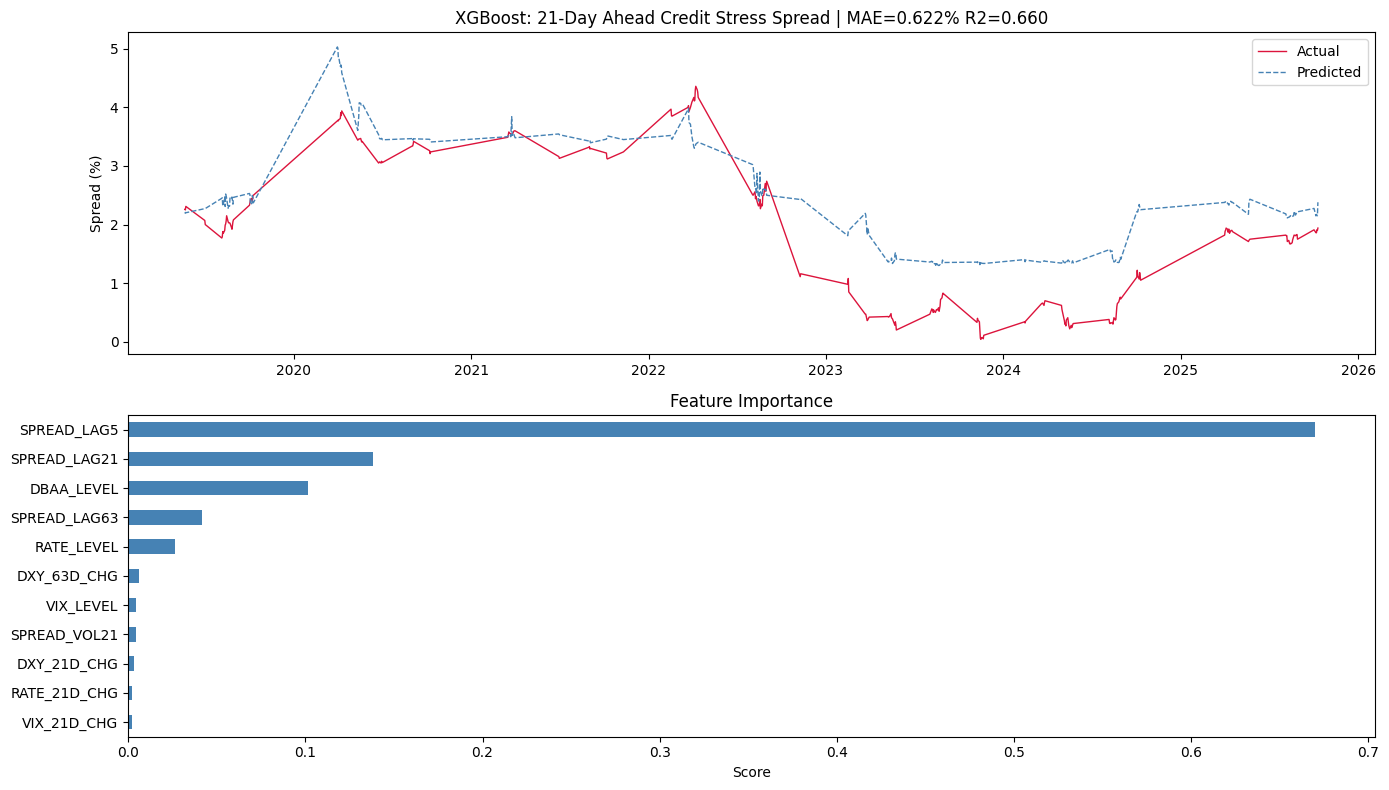

Saved: xgboost_model.pkl, xgboost_results.png


In [3]:
# Phase 2 -- Macro Risk Engine (XGBoost)
# Target: credit stress spread = Moody's BAA yield minus 3M T-Bill yield
# Predicts the spread 21 trading days ahead.
# Walk-forward validation: trained 2006-2019, tested 2019-2025
# Output: xgboost_model.pkl, xgboost_results.png, updated fred_master.csv

import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/fred_master.csv', parse_dates=['date'], index_col='date')

# Target variable: credit stress spread
df['CREDIT_SPREAD'] = df['DBAA'] - df['DGS3MO']

# Feature engineering
df['SPREAD_LAG5']  = df['CREDIT_SPREAD'].shift(5)
df['SPREAD_LAG21'] = df['CREDIT_SPREAD'].shift(21)
df['SPREAD_LAG63'] = df['CREDIT_SPREAD'].shift(63)
df['SPREAD_VOL21'] = df['CREDIT_SPREAD'].rolling(21).std()
df['DXY_21D_CHG']  = df['DTWEXBGS'].pct_change(21) * 100
df['DXY_63D_CHG']  = df['DTWEXBGS'].pct_change(63) * 100
df['VIX_21D_CHG']  = df['VIXCLS'].pct_change(21) * 100
df['VIX_LEVEL']    = df['VIXCLS']
df['RATE_LEVEL']   = df['DGS3MO']
df['RATE_21D_CHG'] = df['DGS3MO'].pct_change(21) * 100
df['DBAA_LEVEL']   = df['DBAA']
df['TARGET']       = df['CREDIT_SPREAD'].shift(-21)

features = [
    'SPREAD_LAG5','SPREAD_LAG21','SPREAD_LAG63','SPREAD_VOL21',
    'DXY_21D_CHG','DXY_63D_CHG','VIX_21D_CHG','VIX_LEVEL',
    'RATE_LEVEL','RATE_21D_CHG','DBAA_LEVEL'
]

df_model  = df[features + ['TARGET']].dropna()
split_idx = int(len(df_model) * 0.70)
split_date = df_model.index[split_idx]

print(f"Dataset: {df_model.shape} | {df_model.index[0].date()} to {df_model.index[-1].date()}")
print(f"Train: up to {split_date.date()} | Test: {split_date.date()} onwards")

X_train = df_model[features].iloc[:split_idx]
y_train = df_model['TARGET'].iloc[:split_idx]
X_test  = df_model[features].iloc[split_idx:]
y_test  = df_model['TARGET'].iloc[split_idx:]

model = XGBRegressor(
    n_estimators=500, learning_rate=0.03, max_depth=4,
    subsample=0.8, colsample_bytree=0.8, random_state=42, verbosity=0
)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
mae    = mean_absolute_error(y_test, y_pred)
r2     = r2_score(y_test, y_pred)
print(f"\nTest MAE: {mae:.3f}%  |  Test R2: {r2:.3f}")

# Save
df.to_csv('../data/fred_master.csv')
with open('../data/xgboost_model.pkl', 'wb') as f:
    pickle.dump(model, f)

# Plot
fig, axes = plt.subplots(2, 1, figsize=(14, 8))
axes[0].plot(y_test.index, y_test.values, label='Actual', color='crimson', linewidth=1)
axes[0].plot(y_test.index, y_pred, label='Predicted', color='steelblue', linewidth=1, linestyle='--')
axes[0].set_title(f'XGBoost: 21-Day Ahead Credit Stress Spread | MAE={mae:.3f}% R2={r2:.3f}')
axes[0].set_ylabel('Spread (%)')
axes[0].legend()
pd.Series(model.feature_importances_, index=features).sort_values(ascending=True).plot(
    kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title('Feature Importance')
axes[1].set_xlabel('Score')
plt.tight_layout()
plt.savefig('../data/xgboost_results.png', dpi=150)
plt.show()
print("Saved: xgboost_model.pkl, xgboost_results.png")


In [4]:
# Phase 3A -- FX Oracle (Lorentzian KNN Regime Classifier)
# Classifies each FX pair into Stable / Trending / Volatile Breakout
# using Lorentzian distance KNN with rolling 252-day normalisation.
#
# Lorentzian distance: D = sum(ln(1 + |xi - yi|))
# Dampens outlier sensitivity vs Euclidean -- important for EM FX pairs
# where central bank interventions create artificial spikes.
#
# Output: fx_oracle_clean.csv
# Note: takes 2-3 minutes to run (KNN over 500 recent days x 4 pairs)

import pandas as pd
import numpy as np

def compute_fx_features(code):
    df_fx = pd.read_csv(f'../data/{code}.csv',
                        parse_dates=['observation_date'], index_col='observation_date')
    df_fx.columns = [code]
    df_fx.replace('.', float('nan'), inplace=True)
    df_fx = df_fx.astype(float)[df_fx.index >= '2005-01-01'].ffill()
    fx = df_fx.copy()
    fx['RETURNS']    = fx[code].pct_change()
    fx['MA21']       = fx[code].rolling(21).mean()
    fx['MA63']       = fx[code].rolling(63).mean()
    fx['VOL21']      = fx['RETURNS'].rolling(21).std() * np.sqrt(252) * 100
    fx['MOMENTUM21'] = fx[code].pct_change(21) * 100
    fx['MOMENTUM63'] = fx[code].pct_change(63) * 100
    fx['TREND']      = fx['MA21'] - fx['MA63']
    fx['SPOT']       = fx[code]
    return fx.dropna()

def rolling_normalize(df, features, window=252):
    df_norm = df[features].copy()
    for col in features:
        rmin  = df[col].rolling(window).min()
        rmax  = df[col].rolling(window).max()
        denom = (rmax - rmin).replace(0, 1)
        df_norm[col] = (df[col] - rmin) / denom
    return df_norm.clip(0, 1)

def lorentzian_distance(a, b):
    return np.sum(np.log1p(np.abs(a - b)))

def classify_regime(row_idx, df_norm, k=21):
    current   = df_norm.iloc[row_idx].values
    distances = []
    for j in range(max(0, row_idx - 252), row_idx):
        past = df_norm.iloc[j].values
        if np.any(np.isnan(past)):
            continue
        distances.append((lorentzian_distance(current, past), j))
    if len(distances) < k:
        return 'Insufficient History'
    distances.sort(key=lambda x: x[0])
    vol_col     = df_norm.columns.get_loc('VOL21')
    future_vols = [
        df_norm.iloc[j+21, vol_col]
        for _, j in distances[:k]
        if j+21 < len(df_norm) and not np.isnan(df_norm.iloc[j+21, vol_col])
    ]
    if not future_vols:
        return 'Stable'
    avg = np.mean(future_vols)
    return 'Stable' if avg < 0.40 else 'Trending' if avg < 0.70 else 'Volatile Breakout'

hedge_cost_map = {'Stable': 40, 'Trending': 80, 'Volatile Breakout': 160, 'Insufficient History': 80}
knn_features   = ['VOL21', 'MOMENTUM21', 'MOMENTUM63', 'TREND']
fx_codes       = ['DEXINUS', 'DEXCHUS', 'DEXSFUS', 'DEXMXUS']

all_results = []
for code in fx_codes:
    print(f"Classifying {code}...")
    fx        = compute_fx_features(code)
    fx_norm   = rolling_normalize(fx, knn_features)
    start_idx = len(fx) - 500
    regimes   = [classify_regime(i, fx_norm) for i in range(start_idx, len(fx))]
    fx_recent = fx.iloc[start_idx:][['SPOT','VOL21','MOMENTUM21','TREND']].copy()
    fx_recent['REGIME']         = regimes
    fx_recent['HEDGE_COST_BPS'] = fx_recent['REGIME'].map(hedge_cost_map)
    fx_recent['FX_CODE']        = code
    all_results.append(fx_recent)
    latest = fx_recent.iloc[-1]
    print(f"  Spot={latest['SPOT']:.4f} | Vol={latest['VOL21']:.1f}% | "
          f"Regime={latest['REGIME']} | Hedge={latest['HEDGE_COST_BPS']} bps")

fx_clean = pd.concat(all_results)
fx_clean.to_csv('../data/fx_oracle_clean.csv')
print("\nSaved: fx_oracle_clean.csv")


Classifying DEXINUS...
  Spot=94.2500 | Vol=6.9% | Regime=Trending | Hedge=80 bps
Classifying DEXCHUS...
  Spot=6.8359 | Vol=2.6% | Regime=Stable | Hedge=40 bps
Classifying DEXSFUS...
  Spot=16.4929 | Vol=15.8% | Regime=Volatile Breakout | Hedge=160 bps
Classifying DEXMXUS...
  Spot=17.3853 | Vol=10.8% | Regime=Trending | Hedge=80 bps

Saved: fx_oracle_clean.csv


In [5]:
# Phase 3B -- Commodity Volatility Adjustment
# Computes 3-year annualised price volatility from IMF Global Commodity
# Price series (sourced via FRED). Scaled to 0-60 bps adjustment range.
# Higher commodity price volatility = higher financing spread.
# Output: commodity_adj.csv

import pandas as pd
import numpy as np

commodity_files = {
    'Copper':    'PCOPPUSDM',
    'Iron Ore':  'PIORECRUSDM',
    'Crude Oil': 'POILBREUSDM',
    'Aluminium': 'PALUMUSDM',
    'Zinc':      'PZINCUSDM',
}

commodity_vol = {}
for name, code in commodity_files.items():
    df_c = pd.read_csv(f'../data/{code}.csv',
                       parse_dates=['observation_date'], index_col='observation_date')
    df_c.columns = [code]
    df_c.replace('.', float('nan'), inplace=True)
    df_c    = df_c.astype(float).dropna()
    vol_3yr = df_c[code].pct_change().rolling(36).std().iloc[-1] * np.sqrt(12) * 100
    commodity_vol[name] = vol_3yr
    print(f"{name}: 3Y annualised vol = {vol_3yr:.1f}%")

min_vol = min(commodity_vol.values())
max_vol = max(commodity_vol.values())

result = pd.DataFrame([
    {'commodity': name,
     'vol_pct':   commodity_vol[name],
     'adj_bps':   int(((commodity_vol[name] - min_vol) / (max_vol - min_vol)) * 60)}
    for name in commodity_vol
])
result.to_csv('../data/commodity_adj.csv', index=False)

print("\nCommodity adjustments (0-60 bps range):")
for _, row in result.iterrows():
    print(f"  {row['commodity']}: {row['adj_bps']} bps  (vol={row['vol_pct']:.1f}%)")
print("\nSaved: commodity_adj.csv")


Copper: 3Y annualised vol = 14.8%
Iron Ore: 3Y annualised vol = 20.4%
Crude Oil: 3Y annualised vol = 30.9%
Aluminium: 3Y annualised vol = 14.6%
Zinc: 3Y annualised vol = 17.4%

Commodity adjustments (0-60 bps range):
  Copper: 0 bps  (vol=14.8%)
  Iron Ore: 21 bps  (vol=20.4%)
  Crude Oil: 60 bps  (vol=30.9%)
  Aluminium: 0 bps  (vol=14.6%)
  Zinc: 10 bps  (vol=17.4%)

Saved: commodity_adj.csv


In [6]:
# Live Pricing Snapshot
# Runs the full pricing engine for a sample deal.
# Change the deal parameters below to test different scenarios.
# This replicates what the Streamlit app computes interactively.

import pandas as pd
import numpy as np
import pickle

df   = pd.read_csv('../data/fred_master.csv', parse_dates=['date'], index_col='date')
fx   = pd.read_csv('../data/fx_oracle_clean.csv', parse_dates=['observation_date'], index_col='observation_date')
comm = pd.read_csv('../data/commodity_adj.csv', index_col='commodity')
corr = pd.read_csv('../data/corridor_map.csv', index_col='corridor')

with open('../data/xgboost_model.pkl', 'rb') as f:
    model = pickle.load(f)

features = [
    'SPREAD_LAG5','SPREAD_LAG21','SPREAD_LAG63','SPREAD_VOL21',
    'DXY_21D_CHG','DXY_63D_CHG','VIX_21D_CHG','VIX_LEVEL',
    'RATE_LEVEL','RATE_21D_CHG','DBAA_LEVEL'
]

# ── Deal parameters (edit these) ──────────────────────────────────────────────
invoice_value     = 5_000_000
tenor_days        = 90
commodity         = 'Copper'          # Copper | Iron Ore | Crude Oil | Aluminium | Zinc
corridor          = 'Africa to Asia'  # Asia to Europe | Americas to Asia | Africa to Asia
                                      # Middle East to Asia | Asia to Americas
profit_margin_bps = 150
# ─────────────────────────────────────────────────────────────────────────────

base_rate            = df['DGS3MO'].dropna().iloc[-1]
base_rate_bps        = base_rate * 100
latest_features      = df[features].dropna().iloc[-1]
latest_date          = df[features].dropna().index[-1]
predicted_spread_pct = float(model.predict(latest_features.values.reshape(1,-1))[0])
risk_premium_bps     = predicted_spread_pct * 100

fx_code      = corr.loc[corridor, 'fx_code']
fx_pair_name = corr.loc[corridor, 'fx_pair']
fx_latest    = fx[fx['FX_CODE'] == fx_code].iloc[-1]
fx_regime    = fx_latest['REGIME']
fx_hedge_bps = float(fx_latest['HEDGE_COST_BPS'])
fx_spot      = float(fx_latest['SPOT'])
fx_vol       = float(fx_latest['VOL21'])

comm_bps      = int(comm.loc[commodity, 'adj_bps'])
comm_vol      = float(comm.loc[commodity, 'vol_pct'])
tenor_adj_bps = int((tenor_days - 90) / 30 * 10)

total_bps        = base_rate_bps + risk_premium_bps + fx_hedge_bps + comm_bps + tenor_adj_bps + profit_margin_bps
total_rate       = total_bps / 100
finance_cost_usd = invoice_value * (total_rate / 100) * (tenor_days / 365)

print("=" * 55)
print("  STF-ALPHA-PRICER -- LIVE SNAPSHOT")
print("=" * 55)
print(f"  As of:              {latest_date.date()}")
print(f"  Commodity:          {commodity}  ({comm_vol:.1f}% 3Y vol)")
print(f"  Corridor:           {corridor}")
print(f"  FX Pair:            {fx_pair_name}  Spot: {fx_spot:.4f}")
print(f"  FX Regime:          {fx_regime}")
print("-" * 55)
print(f"  Base Rate:          {base_rate_bps:.0f} bps  ({base_rate:.2f}%)")
print(f"  Macro Risk Premium: {risk_premium_bps:.0f} bps  ({predicted_spread_pct:.2f}%)")
print(f"  FX Hedge Cost:      {fx_hedge_bps:.0f} bps")
print(f"  Commodity Adj:      {comm_bps:.0f} bps")
print(f"  Tenor Adj:          {tenor_adj_bps:.0f} bps")
print(f"  Profit Margin:      {profit_margin_bps:.0f} bps")
print("-" * 55)
print(f"  ALL-IN RATE:        {total_bps:.0f} bps  ({total_rate:.2f}%)")
print(f"  Finance Cost:       ${finance_cost_usd:,.0f} on ${invoice_value:,.0f} for {tenor_days}d")
print("=" * 55)


  STF-ALPHA-PRICER -- LIVE SNAPSHOT
  As of:              2026-04-02
  Commodity:          Copper  (14.8% 3Y vol)
  Corridor:           Africa to Asia
  FX Pair:            USD/ZAR  Spot: 16.4929
  FX Regime:          Volatile Breakout
-------------------------------------------------------
  Base Rate:          368 bps  (3.68%)
  Macro Risk Premium: 253 bps  (2.53%)
  FX Hedge Cost:      160 bps
  Commodity Adj:      0 bps
  Tenor Adj:          0 bps
  Profit Margin:      150 bps
-------------------------------------------------------
  ALL-IN RATE:        931 bps  (9.31%)
  Finance Cost:       $114,769 on $5,000,000 for 90d


In [7]:
import shutil
import os

# Copy all required data files into app/ so they deploy together
files_to_copy = [
    'fred_master.csv',
    'fx_oracle_clean.csv',
    'commodity_adj.csv',
    'corridor_map.csv',
    'xgboost_model.pkl',
]

src = '../data'
dst = '../app/data'
os.makedirs(dst, exist_ok=True)

for f in files_to_copy:
    shutil.copy(os.path.join(src, f), os.path.join(dst, f))
    print(f"Copied: {f}")

print("\nAll files copied to app/data/")

Copied: fred_master.csv
Copied: fx_oracle_clean.csv
Copied: commodity_adj.csv
Copied: corridor_map.csv
Copied: xgboost_model.pkl

All files copied to app/data/


In [8]:
with open('../app/app.py', 'r', encoding='utf-8') as f:
    content = f.read()

content = content.replace("'../data/", "'data/")

with open('../app/app.py', 'w', encoding='utf-8') as f:
    f.write(content)

print("Paths updated.")

Paths updated.
